In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Veri seti indiriliyor
print("Veri seti indiriliyor...")
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")
print("Veri seti konumu:", path)

# İndirilen klasörün içeriğine göre ana dizini belirleyelim
# Genelde indirilen yolda 'data' klasörü olur
base_dir = os.path.join(path, "data")
categories = ['with_mask', 'without_mask']

data = []
for category in categories:
    folder_path = os.path.join(base_dir, category)
    label = categories.index(category)
    for img in os.listdir(folder_path):
        data.append([os.path.join(folder_path, img), label])

df = pd.DataFrame(data, columns=['filename', 'label'])
df['label'] = df['label'].astype(str)

Veri seti indiriliyor...
Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Veri seti konumu: /kaggle/input/face-mask-dataset


In [7]:
# %20 Test ayrımı
train_val_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])

# Eğitim+Val içinden %20 Validasyon ayrımı
train_df, val_df = train_test_split(train_val_df, test_size=0.20, random_state=42, stratify=train_val_df['label'])

print(f"Eğitim: {len(train_df)}, Validasyon: {len(val_df)}, Test: {len(test_df)}")

Eğitim: 4833, Validasyon: 1209, Test: 1511


In [8]:
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_val_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label', target_size=(224,224), batch_size=32, class_mode='categorical')
val_gen = test_val_datagen.flow_from_dataframe(val_df, x_col='filename', y_col='label', target_size=(224,224), batch_size=32, class_mode='categorical')
test_gen = test_val_datagen.flow_from_dataframe(test_df, x_col='filename', y_col='label', target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)

Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.


In [9]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/100
 45/152 ━━━━━━━━━━━━━━━━━━━━ 5:12 3s/step - accuracy: 0.8209 - loss: 0.3877

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


152/152 ━━━━━━━━━━━━━━━━━━━━ 415s 2s/step - accuracy: 0.9497 - loss: 0.1347 - val_accuracy: 0.9620 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 85s 556ms/step - accuracy: 0.9752 - loss: 0.0721 - val_accuracy: 0.8246 - val_loss: 0.6040 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 83s 545ms/step - accuracy: 0.9766 - loss: 0.0717 - val_accuracy: 0.9644 - val_loss: 0.1659 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 85s 556ms/step - accuracy: 0.9671 - loss: 0.0967 - val_accuracy: 0.8999 - val_loss: 0.2973 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 84s 550ms/step - accuracy: 0.9814 - loss: 0.0589 - val_accuracy: 0.9620 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 147s 584ms/step - accuracy: 0.9911 - loss: 0.0266 - val_accuracy: 0.9735 - val_loss: 0.0947 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 91s 594ms/step - accuracy: 0.9878 - 

48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 534ms/step


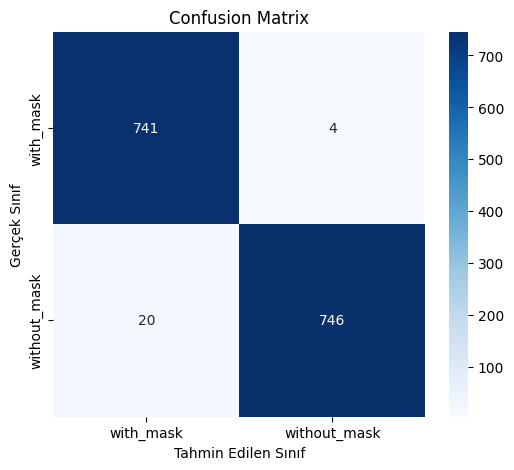

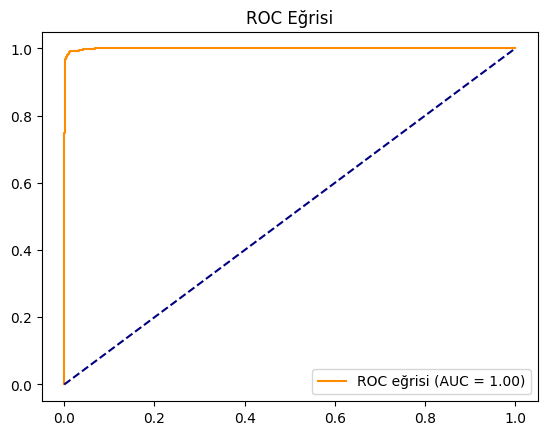

              precision    recall  f1-score   support

   with_mask       0.97      0.99      0.98       745
without_mask       0.99      0.97      0.98       766

    accuracy                           0.98      1511
   macro avg       0.98      0.98      0.98      1511
weighted avg       0.98      0.98      0.98      1511

Specificity (Özgüllük): 0.9946


In [11]:
# Metriklerin Hesaplanması
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()

# 2. ROC ve AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC eğrisi (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")
plt.show()

# 3. Tüm Metrikler
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(classification_report(y_true, y_pred, target_names=categories))
print(f"Specificity (Özgüllük): {specificity:.4f}")